# Emerging Technologies
**Name**: Macdarach Carty Joyce <br>
**ID**: G00394925

## Introduction


In [1]:
import numpy as np
import random
import itertools
import qiskit
import qiskit_aer as aer
import matplotlib.pyplot as plt
import pylatexenc

## Problem 1: Generating Random Boolean Functions
<hr>
<br>
This problem relates to the implementation of a function that returns a boolean output based on a fixed number of boolean inputs. The function may either be <b>constant</b> (always return <code>True</code> or <code>False</code>) or <b>balanced</b> (half of possible combinations return <code>True</code>). This is achieved by generating and returning a function from <i>within</i> another function, the former of which then outputs a boolean output. The goal is to implement this so that the nature of the function (be it constant or balanced) remains unknown to the observer.  

In this case, for $x=\{0,1\}$, a randomly chosen function will either be: 
- **Constant**: Always return 0 ($f_1$) or always return 1 ($f_4$) regardless of input combination.
- **Balanced**: Return 0 for half of the input combinations and 1 for the other half ($f_2, f_2$).   

| $x$ | $f_1(x)$ | $f_2(x)$ | $f_3(x)$ | $f_4(x)$ |
|-----|----------|----------|----------|----------|
|  0  |     0    |     0    |     1    |     1    |
|  1  |     0    |     1    |     0    |     1    |

The approach used here begins with the generation of all possible binary strings of length $n$. If $n = 4$, this would mean generating $2^4$ possible combinations of binary strings: $[0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0], [0, 0, 1, 1],...[1, 1, 1, 1]$. Once all possible combinations are acquired, only the constant (all 0's or 1's) or balanced (exactly half 1's) strings are returned.

In [2]:
def constant_and_balanced_strings(n):
    """
    Generates all constant and balanced binary strings of length n.
    
    Parameters:
        n (int): Length of the binary strings.
    Returns:
        np.ndarray: Array of constant and balanced binary strings.
    """
    # Generate all possible binary strings of length n
    all_binary_strings = ((np.arange(2**n)[:, None] & (1 << np.arange(n-1, -1, -1))) > 0).astype(int)

    # Acquire the sum of ones in each binary string
    ones = all_binary_strings.sum(axis=1)

    # Length of a binary string
    str_len = all_binary_strings.shape[1]

    # Return only the constant (all 0s or all 1s) or balanced (equal number of 0s and 1s) strings
    return all_binary_strings[(ones == 0) | (ones == str_len) | (ones == str_len // 2)]

Once the relevant strings have been returned, a random choice is made to either use a constant or balanced string before proceeding to choose a random string of either category. An inner variadic function is generated which maps the boolean inputs to the randomly selected string using standard binary-to-decimal conversion to calculate the index.  

Given $n$ binary inputs, the binary-to-decimal conversion formula would be as follows: <br>
<br>
$b_0 \times 2^0 + b_1 \times 2^1 ... + b_{n-1} \times 2^{n-1}$

So, given a balanced truth table of $[1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0]$, and the boolean inputs $(0, 1, 0, 1)$, by reversing the bit order to start with the least significant bit, we calculate the index as: <br>
<br>
$1 \times 2^0 + 0 \times 2^1 + 1 \times 2^2 + 0 \times 2^3 = 1 + 0 + 4 + 0 = 5$. 

Element $[5]$ is then acquired from the above truth table, which is $0$. Therefore, the specific input combination of $(0, 1, 0, 1)$ returns an output of 0.

In [3]:
def random_constant_balanced(n):
    """
    Creates and returns a function that randomly selects a binary string.

    Parameters:
        n (int): Number of input bits for the function.
    Returns:
        function: A function that maps n inputs to a randomly selected constant or balanced binary string.
    """
    
    # Acquire all constant and balanced strings of length 2^n
    strings = constant_and_balanced_strings(2 ** n)

    constant_strings = [s for s in strings if s.sum() == 0 or s.sum() == len(s)]
    balanced_strings = [s for s in strings if s.sum() == len(s) // 2]

    # Decide whether to select a constant or balanced string.
    string_type = random.choice(['constant', 'balanced'])

    # Randomly select one of these strings
    if string_type == 'constant':
        random_string = random.choice(constant_strings)
    else:
        random_string = random.choice(balanced_strings)

    
    def f(*args):
        """
        Maps n inputs to the corresponding bit in the randomly selected binary string.

        Parameters:
            *args: n binary inputs (0 or 1).
        Returns:
            int: The bit in the random string corresponding to the binary index formed by the inputs.
        """

        index = 0

        # Get index from binary inputs
        for i, bit in enumerate(reversed(args)):
            # Calculate the index in decimal (bit*2^0 + bit*2^1 + ... + bit*2^(n-1))
            index += (bit * (2 ** i))
            
        return int(random_string[index])
    
    # Store n as an attribute for later use
    f.n = n
    
    return f

### Test the function

In [4]:
# Acquire the function 
f = random_constant_balanced(4)

In [5]:
# Test the function with binary inputs
print(f(1, 1, 1, 1))

1


## Problem 2: Classical Testing for Function Type
<hr>

This section involves determining whether the function previously generated in Problem 1 is constant or balanced. In this approach, this is determined by iterating through all possible input combinations against the truth table and analysing the output of <code>f</code>. There are **two rules** at play here for determining the outcome:

1. If an output is different than the previous, the function must be **balanced**; it cannot be constant if any outputs are different.
2. If over half of the outputs are the same, then the function must be **constant**; it can only be balanced if no more than half of the outputs are the same.

This can be determined after a minimum of 2 iterations (where the function is balanced), or after a maximum of ($2^{n-1} + 1$) iterations, where $n$ is equivalent to the number of input bits. If $n = 4$, with $2^4 = 16$ possible combinations, at most 9 iterations would be necessary. 

In [6]:
def determine_contant_balanced(f):
    """
    Determines whether the given function is constant (returns 0 or 1 for all inputs) or 
    balanced (returns 0 for half of the inputs, 1 for the other half).

    Parameters: 
        f (function): The generated function being tested.

    Retuns:
        A string saying whether the function is constant or balanced.
    """
    
    n = f.n  # Get number of inputs from the function attribute
    previous_output = None
    same_bits = 0
    
    # Calculate threshold: 2^(n-1)
    threshold = 2 ** (n - 1)

    # Generate all possible input combinations dynamically
    all_inputs = itertools.product([0, 1], repeat=n)
    
    # Run f for all possible input combinations
    for i, inputs in enumerate(all_inputs):        
        out = f(*inputs)
        
        if previous_output is not None:
            # Output is different across different input combinations -- must be balanced.
            if out != previous_output:
                return "Balanced"
            else:
                same_bits += 1
        
        # Over half outputs being the same means it cannot be balanced.
        if same_bits > threshold:
            return "Constant"

        previous_output = out
    
    return "Constant"  # If all outputs are the same

In [7]:
determine_contant_balanced(f)

'Constant'

## Problem 3: Quantum Oracles
<hr>

Quantum Oracles implement the transformation: <br><br>
$x\rangle|y\rangle \rightarrow |x\rangle|y \oplus f(x)\rangle$

They essentially act as black-box operations with an unknown property. With the operation being unknown to the observer, the only properties that are known are the inputs supplied and the given outputs. With regards to the previous problems; in the case of a single input, there are four possible Boolean functions. This section sees the creation of a quantum oracle using *Qiskit* for each of the possible single-Boolean-input functions.   

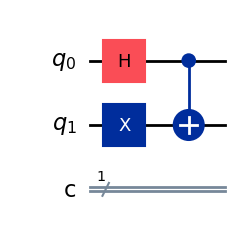

In [10]:
qc = qiskit.QuantumCircuit(2, 1)

qc.x(1)
qc.h(0)
qc.cx(0, 1)
qc.draw(output='mpl')

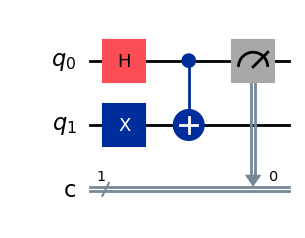

In [11]:
qc.measure(0, 0)
qc.draw(output='mpl')

In [12]:
oracle = qiskit.QuantumCircuit(2)
oracle.barrier()
oracle.cx(0, 1)
oracle.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

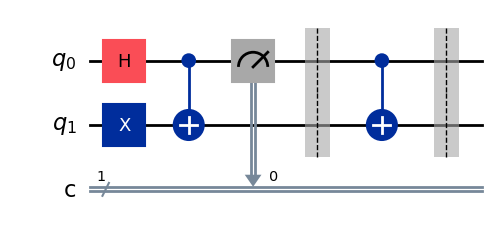

In [13]:
qc.compose(oracle, inplace=True)
qc.draw(output='mpl')

## Problem 4: Deutsch's Algorithm with Qiskit

## Problem 5: Scaling to the Deutsch-Jozsa Algorithm